## DPD ML based



# Imports

In [2]:
# --- Colab setup: install packages that are not preinstalled on Colab ---
import importlib.util
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB or importlib.util.find_spec("mplcursors") is None:
    %pip install -q torchinfo mplcursors


In [ ]:
import csv
import matplotlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
random.seed(1234)
from torchinfo import summary
from dataclasses import dataclass
from typing import ClassVar
from typing import Literal
import mplcursors
from pathlib import Path

from sympy import false as sym_false, true as sym_true
from datetime import datetime
np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f'{device=}, {torch.cuda.is_available()=}, {torch.version.cuda=}, {torch.backends.cudnn.enabled=}, {torch.backends.cudnn.version()=}, {torch.backends.cudnn.is_available()=}')

xx = 1;

# %matplotlib notebook # Interactive plots inside notebook
 # Static plots inside notebook
# %matplotlib inline
# %matplotlib qt
# Requires ipympl for richer interactivity
# %matplotlib widget 
# %matplotlib qt # Opens plots in a separate window (needs PyQt5)






TypeError: is_acceptable() missing 1 required positional argument: 'tensor'

## Configuration parameters


In [ ]:
def _build_data_carriers(pilot_carriers: list[int]) -> list[int]:
    """Return OFDM data carriers excluding DC and pilot tones."""
    return [k for k in range(-26, 26) if k != 0 and k not in pilot_carriers]

@dataclass
class Config:
    """Main configuration class for DPD pipeline and analysis."""
    tx_sample_rate: float = 20e6
    dpd_sample_rate: float = tx_sample_rate*8  # 640e6
    signal_rms_dbp: float = -15.0  # backoff to ~15 dB below saturation
    FFT_SIZE: ClassVar[int] = 64*8 # 2048
    CP_LEN: ClassVar[int] = 64*8//4 # 512
    PILOT_CARRIERS: ClassVar[list[int]] = [-21, -7, 7, 21]
    PILOT_VALUES: ClassVar[list[int]] = [1, 1, 1, -1]
    DATA_CARRIERS: ClassVar[list[int]] = _build_data_carriers(PILOT_CARRIERS)
    Ka: int = 4  # polynmial order
    La: int = 3    # memory depth
    Kb: int = 4  # negative lagging polynomial order
    Lb: int = 3    # negative lagging memory depth
    Mb: int = 1    # negative lagging order
    Kc: int = 4  # positive lagging polynomial order
    Lc: int = 3    # positive lagging memory depth
    Mc: int = 1    # positive lagging order
    Ncoeff: int = Ka*La + Kb*Lb*Mb + Kc*Lc*Mc  # total number of DPD coefficients
    Nvec_cal_mat: int = Ncoeff  # number of vectors used in calibration matrix
    start_data_index = np.max([La, Lb + Mb, Lc - Mc])
    iterations_per_sym: int = 200  # number of iterations per OFDM symbol (for tracking)


## signal generator

In [24]:
from dpd_ml_project import config



_FFT_SIZE = config.Config.FFT_SIZE
_CP_LEN = config.Config.CP_LEN
_PILOT_CARRIERS = config.Config.PILOT_CARRIERS
_PILOT_VALUES = config.Config.PILOT_VALUES
_DATA_CARRIERS = config.Config.DATA_CARRIERS


def _bpsk_map(bits: np.ndarray) -> np.ndarray:
    bits = np.asarray(bits, dtype=int)
    return np.where(bits == 0, 1 + 0j, -1 + 0j).astype(complex)


def _data_subcarriers() -> list[int]:
    used = [k for k in range(-26, 26) if k != 0]
    return [k for k in used if k not in _PILOT_CARRIERS]


def _carrier_to_index(k: int) -> int:
    return k % _FFT_SIZE



def gen_lsig(
    bypass: bool = False,
    signal_rms_dbp: float = config.Config.signal_rms_dbp,
    repeat_bits_every_call: bool = False,
    bits_seed: int = 0,
) -> np.ndarray:
    """Generate one OFDM symbol with BPSK data (80 samples with CP).

    If repeat_bits_every_call=True, the same random bit pattern is generated on each
    function call using bits_seed. If False, a fresh random bit pattern is generated.
    """
    _ = bypass  # source module keeps same behavior; flag kept for unified API

    # L-SIG is generated with random BPSK data
    # Note: in real Wi-Fi, L-SIG is encoded with a fixed rate-1/2 code and known bits, 
    # but for our purposes random bits are sufficient to test the signal processing chain.
    if repeat_bits_every_call:
        rng = np.random.default_rng(bits_seed)
        random_bits = rng.integers(0, 2, size=48)
    else:
        random_bits = np.random.randint(0, 2, size=48)
    data_symbols = _bpsk_map(random_bits)

    # place data and pilots in the frequency domain
    xf = np.zeros(_FFT_SIZE, dtype=complex)
    for carrier, sym in zip(_DATA_CARRIERS, data_symbols):
        xf[_carrier_to_index(carrier)] = sym
    for carrier, pilot in zip(_PILOT_CARRIERS, _PILOT_VALUES):
        xf[_carrier_to_index(carrier)] = complex(pilot, 0.0)

    # IFFT to time domain
    x_time = np.fft.ifft(np.asarray(xf, dtype=np.complex128), norm="ortho")
    # add cyclic prefix
    cp = x_time[-_CP_LEN:]
    x_time_w_cp = np.concatenate((cp, x_time))

    # --- Normalize input power ---
    x_time_w_cp = x_time_w_cp / (np.sqrt(np.mean(np.abs(x_time_w_cp)**2)) + 1e-12)
    rms_db = 10 * np.log10(np.mean(np.abs(x_time_w_cp)**2) + 1e-12)
    x_time_w_cp = x_time_w_cp * 10**(signal_rms_dbp/20)

    return x_time_w_cp

## AWGN

In [25]:
def apply_awgn(tx_iq: np.ndarray, snr_db: float = 70, bypass: bool = False) -> np.ndarray:
    """
    Additive White Gaussian Noise (AWGN) channel model.
    
    Parameters:
        tx_iq : list of complex (baseband IQ)
        snr_db: signal-to-noise ratio in dB (default 70)
    
    Returns:
        y : complex numpy array (AWGN channel output)
    """

    
    tx_iq = np.asarray(tx_iq, dtype=complex).reshape(-1)

    if bypass:
        return tx_iq.copy()

    signal_rms_db = 10 * np.log10(np.mean(np.abs(tx_iq)**2));

    noise_rms_db = signal_rms_db - snr_db
    noise = 10**(noise_rms_db/20) * (np.random.randn(len(tx_iq)) + 1j * np.random.randn(len(tx_iq)))
    y = tx_iq + noise

    return y

## PA model

In [26]:
def apply_pa_model(x: np.ndarray, fs=640e6, bypass: bool = False) -> np.ndarray:
    """
    Behavioral PA model approximating Skyworks SKY85355-class FEM.
    
    Parameters:
        tx_iq : list of complex (baseband IQ)
        fs: sampling frequency (Hz), default 640 MHz
    
    Returns:
        y : complex numpy array (PA output)
    """

    
    x = np.asarray(x, dtype=complex).reshape(-1)

    if bypass:
        return x.copy()

    snr_db = 70
    

    # --- AM-AM: Rapp model (typical WLAN PA compression) ---
    # Smooth saturation, no hard clipping
    p = 3.0             # smoothness factor
    A_sat = 1.0         # saturation amplitude
    r = np.abs(x)

    am_am = r / (1 + (r / A_sat)**(2 * p))**(1 / (2 * p))

    # --- AM-PM: mild phase distortion (typical WiFi PA) ---
    # few degrees near compression
    phi_max = np.deg2rad(8)   # max ~8 deg
    am_pm = phi_max * (r / A_sat)**2 / (1 + (r / A_sat)**3)

    # Apply AM-AM + AM-PM
    y = am_am * np.exp(1j * (np.angle(x) + am_pm))

    # --- Memory effects (weak, thermal/bias dynamics) ---
    # Simple IIR envelope memory
    env = np.abs(y)
    alpha = 0.98  # strong memory (slow thermal effect)
    env_mem = lfilter([1-alpha], [1, -alpha], env)

    # Gain droop with memory (supply/bias compression)
    k_mem = 0.15
    y = y * (1 - k_mem * env_mem)

    # --- Optional: mild spectral regrowth shaping ---
    # add small cubic memory polynomial term
    beta = 0.08
    delay = int(fs * 1e-9)  # ~1 ns electrical memory

    if delay > 0:
        x_del = np.concatenate([np.zeros(delay, dtype=complex), x[:-delay]])
        y += beta * x_del * np.abs(x_del)**2

    return y


## GMP predistortion

In [27]:
def apply_predistortion(
    tx_iq: np.ndarray,
    coeffs: np.ndarray,
    bypass: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply a GMP predistortion model.

    """
    # initialize local variables from config
    _Ka = config.Config.Ka
    _La = config.Config.La
    _Kb = config.Config.Kb
    _Lb = config.Config.Lb
    _Mb = config.Config.Mb
    _Kc = config.Config.Kc
    _Lc = config.Config.Lc
    _Mc = config.Config.Mc
    _num_coeffs = config.Config.Ncoeff

    tx_iq = np.asarray(tx_iq, dtype=complex).reshape(-1)
    coeffs = np.asarray(coeffs, dtype=complex).reshape(-1)

    # Initialize y_ordered matrix
    _num_samples = len(tx_iq)
    y_ordered = np.zeros((_num_samples, _num_coeffs), dtype=complex)
                                  
    if bypass:
        return tx_iq.copy(), y_ordered

    # non lagging polynomial terms calculation
    for indx_x in range(len(tx_iq)):
        for k in range(_Ka):
            for l in range(_La):
                x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                y_ordered[indx_x][k * _La + l] = x_current * abs(x_current) ** (k)

    # negative lagging polynomial terms calculation
    for indx_x in range(len(tx_iq)):
        for k in range(_Kb):
            for l in range(_Lb):
                for m in range(1,_Mb+1):
                    x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                    x_current_cross = tx_iq[indx_x - l - m] if indx_x - l - m >= 0 else 0j
                    y_ordered[indx_x][_Ka*_La + k * (_Lb * _Mb) + l * _Mb + (m-1)] = x_current * abs(x_current_cross) ** (k)

    # positive lagging polynomial terms calculation
    for indx_x in range(len(tx_iq)):
        for k in range(_Kc):
            for l in range(_Lc):
                for m in range(1, _Mc+1):
                    x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                    cross_idx = indx_x - l + m
                    x_current_cross = tx_iq[cross_idx] if 0 <= cross_idx < len(tx_iq) else 0j
                    y_ordered[indx_x][_Ka*_La + _Kb*_Lb*_Mb + k * (_Lc * _Mc) + l * _Mc + (m-1)] = x_current * abs(x_current_cross) ** (k)

    # calculate the output signal by multiplying the ordered matrix with the coefficients
    y_out = y_ordered @ coeffs

    return y_out, y_ordered

## traditional calibration

# Kalman

In [28]:
def estimate_coefficients_kal(
    calibrator,  # Calibrator instance
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> np.ndarray:
    """Estimate DPD coefficients using Kalman filter.
    
    Accesses P_kal from the Calibrator instance to maintain state across iterations.

    Args:
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 
        calibrator: Calibrator instance (has access to self.P_kal).

    Returns:
        List of complex coefficients.
    """
   
    start_data_index = config.Config.start_data_index
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)

    # scalar Kalman filter update
    for n in range(len(tx_prd_out) - start_data_index):

        phi = np.array(y_ordered[start_data_index + n], dtype=complex)        
        phi = phi.reshape(-1, 1)  # column vector
        x = tx_prd_out[start_data_index + n]  # scalar

        # prediction step (no process noise, so prediction is just previous state)
        theta_pred = np.asarray(calibrator.coeffs, dtype=complex).reshape(-1, 1)  # column vector
        P_pred = calibrator.P_kal + calibrator.Q_kal  # predicted covariance is previous covariance plus process noise

        # Kalman gain
        denom = phi.conj().T @ P_pred @ phi + calibrator.R_kal  # scalar
        K = P_pred @ phi / denom  # column vector (Mx1)

        # update step
        innovation = x - (phi.conj().T @ theta_pred).item()  # scalar
        theta_upd = theta_pred + K * innovation  # column vector (Mx1)
        P_upd = (np.eye(len(K)) - K @ phi.conj().T) @ P_pred  # updated covariance

        # store updated state and covariance back in calibrator
        calibrator.coeffs = theta_upd.reshape(-1)
        calibrator.P_kal = P_upd

    return calibrator.coeffs

# LS

In [29]:
from dpd_ml_project.cal import calibrator

def estimate_coefficients_ls(
    calibrator,  # Calibrator instance        
    rf_out: np.ndarray,
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> "calibrator.Calibrator":
    """Estimate DPD coefficients using batch least-squares method.
    
    Args:
        rf_out: RF output signal.
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 


    Returns:
        Updated (or unchanged) Calibrator instance.
    """
    Ka = config.Config.Ka
    La = config.Config.La
    Kb = config.Config.Kb
    Lb = config.Config.Lb
    Mb = config.Config.Mb
    Kc = config.Config.Kc
    Lc = config.Config.Lc
    Mc = config.Config.Mc
    Ncoeff = config.Config.Ncoeff    
    Nvec_cal_mat = 17

    rf_out = np.asarray(rf_out, dtype=complex).reshape(-1)
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)

    Y = np.zeros((Nvec_cal_mat, Ncoeff), dtype=complex)

    start_data_index = np.max([La, Lb + Mb, Lc - Mc])

    # non lagging polynomial terms
    vec_index = -1
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = -1
        for k in range(Ka):
            for l in range(La):
                coeff_index += 1
                x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                Y[vec_index, coeff_index] = x_current * abs(x_current) ** (k)

    # negative lagging polynomial terms
    vec_index = -1
    locked_coeff_index = coeff_index
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = locked_coeff_index
        for k in range(Kb):
            for l in range(Lb):
                for m in range(1, Mb+1):
                    coeff_index += 1
                    x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                    x_current_cross = rf_out[indx_x - l - m] if indx_x - l - m >= 0 else 0j
                    Y[vec_index, coeff_index] = x_current * abs(x_current_cross) ** (k)

    # positive lagging polynomial terms
    vec_index = -1
    locked_coeff_index = coeff_index
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = locked_coeff_index
        for k in range(Kc):
            for l in range(Lc):
                for m in range(1, Mc+1):
                    coeff_index += 1
                    x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                    cross_idx = indx_x - l + m
                    x_current_cross = rf_out[cross_idx] if 0 <= cross_idx < len(rf_out) else 0j
                    Y[vec_index, coeff_index] = x_current * abs(x_current_cross) ** (k)

    y_ordered = y_ordered[start_data_index:start_data_index+Nvec_cal_mat]
    X = tx_prd_out[start_data_index:start_data_index+Nvec_cal_mat]
    W = np.linalg.pinv(y_ordered) @ X
    calibrator.coeffs = np.asarray(W, dtype=complex).reshape(-1)
    
    return calibrator

# RLS

In [30]:
from dpd_ml_project.cal import calibrator


def estimate_coefficients_rls(
    calibrator,  # Calibrator instance
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> "calibrator.Calibrator":
    """Estimate DPD coefficients using recursive least-squares method.
    
    Args:
        calibrator: Calibrator instance.
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 
    Returns:
        Updated (or unchanged) Calibrator instance.
    """
    start_data_index = config.Config.start_data_index
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)
    omega_n = np.asarray(calibrator.coeffs, dtype=complex).reshape(-1, 1)

    # scalar RLS update
    for n in range(len(tx_prd_out) - start_data_index):
    # for n in range(100):
        lambda_pm1 = calibrator.lambda_rls**-1
        u = y_ordered[start_data_index + n]  # input vector (monomials)
        u = np.array(u, dtype=complex).reshape(1, -1)  # row vector
        gamma_n = 1/(1+ lambda_pm1 * u @ calibrator.P_rls @ u.conj().T)  # scalar
        g_n = lambda_pm1 * gamma_n * calibrator.P_rls @ u.conj().T  # gain vector (Mx1)
        e_n = tx_prd_out[start_data_index + n] - u @ omega_n  # scalar
        omega_n = omega_n + g_n * e_n
        calibrator.P_rls = lambda_pm1 * calibrator.P_rls - g_n @ g_n.conj().T / gamma_n  # update RLS covariance
        calibrator.cost_rls = calibrator.lambda_rls * calibrator.cost_rls + gamma_n * np.abs(e_n)**2  # update RLS cost

    calibrator.coeffs = omega_n.reshape(-1)
    return calibrator

# calibration update

In [31]:
class Calibrator:
    """Stateful DPD coefficient estimator.

    Maintains coefficients and Kalman state across iterations so that RLS 
    and Kalman can track changes incrementally.

    Args:
        mode: "ls" for batch least-squares estimation, "rls" for recursive 
              least-squares tracking, "kal" for Kalman estimation.
    """

    def __init__(self, mode: Literal["ls", "rls", "kal"] = "ls") -> None:
        cfg = config.Config()
        Ka = cfg.Ka
        La = cfg.La
        Kb = cfg.Kb
        Lb = cfg.Lb
        Mb = cfg.Mb
        Kc = cfg.Kc
        Lc = cfg.Lc
        Mc = cfg.Mc
        num_a_coeffs = Ka * La
        num_b_coeffs = Kb * Lb * Mb
        num_c_coeffs = Kc * Lc * Mc
        self.Nvec_cal_mat = config.Config.Nvec_cal_mat      # Number of vectors used for calibration matrix
        self.mode: Literal["ls", "rls", "kal"] = mode
        self.coeffs: np.ndarray = np.ones((num_a_coeffs + num_b_coeffs + num_c_coeffs,), dtype=complex)
        # Kalman filter initialization
        self.P_kal = np.eye(config.Config.Ncoeff)  # Kalman covariance matrix, persists across iterations
        self.R_kal = 1e-6   # Kalman measurement noise covariance
        self.Q_kal = 1e-6 * np.eye(config.Config.Ncoeff)  # Kalman process noise covariance
        # RLS initialization
        self.P_rls = np.eye(config.Config.Ncoeff)  # RLS covariance matrix
        self.lambda_rls = 0.99  # RLS forgetting factor
        self.cost_rls = 0.0  # RLS cost, persists across iterations
        self.e_rls = 0.0  # RLS error, persists across iterations
        self.g_rls = np.zeros((config.Config.Ncoeff, 1), dtype=complex)  # RLS gain vector, persists across iterations


    def update(
        self,
        tx_prd_out: np.ndarray | None = None,
        tx_pod_out: np.ndarray | None = None,
        rf_out: np.ndarray | None = None,
        y_ordered: np.ndarray | None = None,
        bypass: bool = False
    ) -> "Calibrator":
        """Estimate or update DPD coefficients and store them.

        Args:
            tx_prd_out: Predistorted signal output.
            tx_pod_out: Post-distorted signal output.
            rf_out: RF output signal.
            y_ordered: Ordered signal for coefficient estimation.
            bypass: If True, return current coefficients unchanged.

        Returns:
            Updated (or unchanged) Calibrator instance.
        """
        if bypass:
            return self

        if self.mode == "ls":
            self = estimate_coefficients_ls(self, rf_out, tx_prd_out, y_ordered)
        elif self.mode == "rls":
            self = estimate_coefficients_rls(self, tx_prd_out, y_ordered)
        elif self.mode == "kal":
            self = estimate_coefficients_kal(self, tx_prd_out, y_ordered)
        return self


## Single Iteration

In [32]:
from dataclasses import dataclass, field

from dpd_ml_project.cal.calibrator import Calibrator
from dpd_ml_project.channel.pa_model import apply_pa_model
from dpd_ml_project.channel.awgn import apply_awgn
from dpd_ml_project.dpd.dpd import apply_predistortion
from dpd_ml_project.metrics.evm import compute_evm
from dpd_ml_project.metrics.mask import check_relative_mask
from dpd_ml_project.siggen.SigGen import gen_lsig


@dataclass(slots=True)
class ModuleBypass:
    """Configure which modules are bypassed (pass-through)."""
    siggen: bool = True
    estimator: bool = True
    dprd: bool = True # predistortion
    dpod: bool = True # postdistortion    
    awgn: bool = True
    pa_model: bool = True
    capture: bool = True
    evm: bool = True
    mask: bool = True

@dataclass(slots=True)
class SetUpConfig:
    """Configuration for the entire DPD setup."""
    num_ofdm_sym: int = 10
    iterations_per_sym: int = 200
    initial_coeffs: np.ndarray | None = None
    snr_db: float = 70
    signal_rms_dbp: float = -10

@dataclass(slots=True)
class IterationConfig:
    """Configuration for a single DPD iteration.

    Attributes:
        bypass: Module bypass flags (default: all modules active).
        calibrator: Stateful calibrator instance (holds coefficients and
                    estimation mode across iterations).
    """
    bypass: ModuleBypass = field(default_factory=ModuleBypass)
    calibrator: Calibrator = field(default_factory=Calibrator)
    setup: SetUpConfig = field(default_factory=SetUpConfig)
    temperature_celsius: float = 25.0
    iteration_index: int = 0
    iterations_per_sym: int = 200  # number of iterations per OFDM symbol (for tracking)

@dataclass(slots=True)
class IterationResult:
    """Result of a single DPD iteration."""
    status: str = "not_started"
    evm_db: float = 0.0
    mask_pass: bool = False
    siggen_out: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    prd_in_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    pa_in_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    pa_out_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    dpod_out_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    cal_coeffs: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    calibrator_state: Calibrator = field(default_factory=Calibrator)



# -----------------------------------------------------------------------------
# Main iteration entry point
# -----------------------------------------------------------------------------
def run_iteration(config: IterationConfig | None = None) -> IterationResult:
    """Run one DPD iteration with hardcoded data flow.

    Data flow (fixed):
        siggen -> dpd -> pa_model -> capture ->
        -> calibrator -> metrics

    Args:
        config: Iteration configuration (bypass flags, calibration mode).
                Defaults to all modules active with LS estimation.

    Returns:
        IterationResult with status, EVM, mask pass, and IQ vectors.
    """
    cfg = config or IterationConfig()
    bp = cfg.bypass

    # --- Signal generation ---
    tx_iq = gen_lsig(bypass=bp.siggen, repeat_bits_every_call=False, bits_seed=123, signal_rms_dbp=cfg.setup.signal_rms_dbp)

    # --- Apply predistortion with current coefficients ---
    coeffs = np.asarray(cfg.calibrator.coeffs, dtype=complex).reshape(-1)
    tx_prd_out, _ = apply_predistortion(tx_iq, coeffs, bypass=bp.dprd)

    # --- AWGN channel ---
    tx_pa_in_iq = apply_awgn(tx_prd_out, snr_db=cfg.setup.snr_db, bypass=bp.awgn)

    # --- PA / channel model ---
    rf_out = apply_pa_model(tx_pa_in_iq, bypass=bp.pa_model)

    # --- Apply post-distortion with current coefficients --- ---
    tx_pod_out, y_ordered = apply_predistortion(rf_out, coeffs, bypass=bp.dpod)

    # --- Update calibrator (LS or RLS) --- 
    # calibration works @640MHz rate, so use upsampled signal and PA input for estimation
    cfg.calibrator = cfg.calibrator.update(tx_prd_out, tx_pod_out, rf_out, y_ordered, bypass=bp.estimator)
    coeffs = np.asarray(cfg.calibrator.coeffs, dtype=complex).reshape(-1)

    # --- Metrics ---
    n = min(len(tx_iq), len(rf_out))
    evm = compute_evm(reference=tx_iq[:n], measured=rf_out[:n], bypass=bp.evm)
    mask_pass = check_relative_mask(measured=rf_out, bypass=bp.mask)

    status = "ok" if mask_pass else "needs_tuning"


    # # debug
    # ==============================================
    # x_prd = apply_predistortion(tx_iq, cfg.calibrator.coeffs, bypass=False)
    # Y_prd = apply_pa_model(x_prd, bypass=False)


    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 2, 1)
    # plt.plot(np.abs(tx_iq), label='Predistorted Input', color='blue')
    # plt.plot(np.abs(Y_prd), label='prd PA Output', color='orange')
    # plt.plot(np.abs(rf_out), label='PA Output', color='red')
    # plt.title('Magnitude Comparison')
    # plt.xlabel('Sample Index')
    # plt.ylabel('Magnitude')
    # plt.legend()
    # plt.subplot(1, 2, 2)
    # plt.plot(np.angle(tx_iq), label='Predistorted Input', color='blue')
    # plt.plot(np.angle(Y_prd), label='pfd PA Output', color='orange')
    # plt.plot(np.angle(rf_out), label='PA Output', color='red')
    # plt.title('Phase Comparison')
    # plt.xlabel('Sample Index')
    # plt.ylabel('Phase (radians)')
    # plt.legend()
    # plt.tight_layout()
    # # plt.show()
    # ==============================================

    return IterationResult(
        status=status,
        evm_db=evm,
        mask_pass=mask_pass,
        siggen_out=tx_iq,
        prd_in_iq=tx_iq,
        pa_in_iq=tx_pa_in_iq,
        pa_out_iq=rf_out,
        dpod_out_iq=tx_pod_out,
        cal_coeffs=coeffs.copy(),
        calibrator_state=cfg.calibrator,
    )


## Run simulation Analysis - review later TBD

In [ ]:
@dataclass(slots=True)
class BypassAnalysisResult:
    spectrum_plot: Path
    evm_plot: Path
    evm_db: np.ndarray
    mean_evm_db: float


def run_analysis(
    pipeline_result,
    iteration_config: IterationConfig,
    output_dir: Path,
) -> BypassAnalysisResult:


    # definitions for plotting and analysis
    _FFT_SIZE = config.Config.FFT_SIZE
    _CP_LEN = config.Config.CP_LEN
    _DATA_CARRIERS = config.Config.DATA_CARRIERS
    _data_carriers_index = [_carrier_to_index(k) for k in _DATA_CARRIERS]
    _pa_in_start_idx = _CP_LEN//2  # start data index at half of CP


    # capture time domain signals
    siggen_out_no_cp = np.array(pipeline_result.siggen_out[_CP_LEN:])
    dprd_in_no_cp = np.array(pipeline_result.prd_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    pa_in_no_cp = np.array(pipeline_result.pa_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    pa_out_no_cp = np.array(pipeline_result.pa_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    dpod_in_out_cp = np.array(pipeline_result.dpod_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])  # post-distorted signal (PA output)
 

    # visualize the signals in time domain
    fig0, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.plot(np.abs(dprd_in_no_cp), label='Predistorted Input', color='blue')
    ax1.plot(np.abs(pa_in_no_cp), label='PA Input', color='orange')
    ax1.plot(np.abs(pa_out_no_cp), label='PA Output', color='red')
    # ax1.plot(np.abs(dpod_in_out_cp), label='Post-Distorted Output', color='red')
    ax1.set_title('Magnitude Comparison')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Magnitude')
    ax1.legend()
    ax2.plot(np.angle(dprd_in_no_cp), label='Predistorted Input')
    ax2.plot(np.angle(pa_in_no_cp), label='PA Input')
    ax2.plot(np.angle(pa_out_no_cp), label='PA Output')
    # ax2.plot(np.angle(dpod_in_out_cp), label='Post-Distorted Output')
    ax2.set_title('Phase Comparison')
    ax2.set_xlabel('Sample Index')
    ax2.set_ylabel('Phase (radians)')
    ax2.legend()
    mplcursors.cursor(hover=True)
    td_plot = output_dir / f"time_domain_{iteration_config.iteration_index}.png"
    fig0.savefig(td_plot, dpi=140)
    # plt.show()
    

    # convert to frequency domain
    # and calculate PSD
    siggen_out_fd = np.fft.fft(siggen_out_no_cp, n=_FFT_SIZE, norm="ortho")
    dprd_in_fd = np.fft.fft(dprd_in_no_cp, n=_FFT_SIZE, norm="ortho")
    pa_in_fd = np.fft.fft(pa_in_no_cp, n=_FFT_SIZE, norm="ortho")
    pa_out_fd = np.fft.fft(pa_out_no_cp, n=_FFT_SIZE, norm="ortho")
    evm_fd = np.fft.fft(dprd_in_no_cp-pa_out_no_cp, n=_FFT_SIZE, norm="ortho")  # error vector magnitude in frequency domain
    # Spectrum (dB) over all FFT bins
    eps = 1e-12
    siggen_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(siggen_out_fd)) + eps)
    dprd_in_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(dprd_in_fd)) + eps)
    pa_in_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(pa_in_fd)) + eps)
    pa_out_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(pa_out_fd)) + eps)
    evm_fd_db = 20.0 * np.log10(np.abs(evm_fd) + eps)
    bins_index = np.arange(-_FFT_SIZE // 2, _FFT_SIZE // 2)

    fig1, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(bins_index, siggen_fd_db, label="TX")
    ax1.plot(bins_index, dprd_in_fd_db, color="orange", label="TX at PD output")
    ax1.plot(bins_index, pa_out_fd_db, color="green", label="PA output")
    ax1.set_title("Spectrum (FFT bins)")
    ax1.set_xlabel("Subcarrier index (shifted)")
    ax1.set_ylabel("Magnitude (dB)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    spectrum_plot = output_dir / f"spectrum_{iteration_config.iteration_index}.png"
    fig1.tight_layout()
    mplcursors.cursor(hover=True)
    fig1.savefig(spectrum_plot, dpi=140)
    # plt.close(fig1)

    # EVM magnitude per FFT bin (full-bandwidth; subcarrier remapping is not
    # valid for an upsampled signal whose length is not an integer multiple of
    # the original 64-point FFT size)

    fig2, ax2 = plt.subplots(figsize=(9, 4))    
    ax2.plot(_DATA_CARRIERS, evm_fd_db[_data_carriers_index], color="red", label="EVM at used subcarriers")
    ax2.set_title(f"EVM [dB] at used subcarriers")
    ax2.set_xlabel("Subcarrier index")
    ax2.set_ylabel("EVM (dB)")
    ax2.grid(True, alpha=0.3)   
    evm_plot = output_dir / f"evm_{iteration_config.iteration_index}.png"
    fig2.tight_layout()
    mplcursors.cursor(hover=True)
    fig2.savefig(evm_plot, dpi=140)

    return BypassAnalysisResult(
        spectrum_plot=spectrum_plot,
        evm_plot=evm_plot,
        evm_db=np.asarray(evm_fd_db[_data_carriers_index], dtype=float),
        mean_evm_db=10*np.log10(np.mean(10**(evm_fd_db[_data_carriers_index]/20)) + eps),
    )


# run analysis on entire set of iteration results
def run_analysis_all(
    pipeline_results,
    iteration_configs: IterationConfig,
    output_dir: Path,
) -> BypassAnalysisResult:


    # definitions for plotting and analysis
    _FFT_SIZE = config.Config.FFT_SIZE
    _CP_LEN = config.Config.CP_LEN
    _DATA_CARRIERS = config.Config.DATA_CARRIERS
    _data_carriers_index = [_carrier_to_index(k) for k in _DATA_CARRIERS]
    _pa_in_start_idx = _CP_LEN//2  # start data index at half of CP

    siggen_out_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    dprd_in_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    pa_in_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    pa_out_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    dpod_in_out_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)  # post-distorted signal (PA output)    


    # capture time domain signals
    for i, pipeline_result in enumerate(pipeline_results):
        siggen_out_no_cp[i,:] = np.array(pipeline_result.siggen_out[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        dprd_in_no_cp[i,:] = np.array(pipeline_result.prd_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        pa_in_no_cp[i,:] = np.array(pipeline_result.pa_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        pa_out_no_cp[i,:] = np.array(pipeline_result.pa_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        dpod_in_out_cp[i,:] = np.array(pipeline_result.dpod_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])  # post-distorted signal (PA output)
 




    # -------------------------------------
    # meters and plot section
    # -------------------------------------

    # plot frequency domain magnitude
    # test_data_rs  = test_data[:,:,_CP_LEN//2:_NFFT+_CP_LEN//2]
    # test_data_fd = np.fft.fftshift(np.fft.fft(test_data_rs,axis=2),axes=2)
    pa_in_no_cp_fd = np.fft.fftshift(np.fft.fft(pa_in_no_cp,axis=1),axes=1)
    pa_in_no_cp_magdb = 20*np.log10(np.abs(pa_in_no_cp_fd))

    pa_out_no_cp_fd = np.fft.fftshift(np.fft.fft(pa_out_no_cp,axis=1),axes=1)
    pa_out_magdb_fd = 20*np.log10(np.abs(pa_out_no_cp_fd))
    # test_data_magdb_fd = 20*np.log10((np.mean(np.abs(test_data_fd),axis=0)))
    # rf_out_rs = rf_out.reshape(num_ofdm_sym,-1)[:,_CP_LEN//2:_NFFT+_CP_LEN//2]
    # rf_out_fd = np.fft.fftshift(np.fft.fft(rf_out_rs,axis=1),axes=1)
    # rf_out_magdb_fd = 20*np.log10(np.mean(np.abs(rf_out_fd),axis=0))

    plt.figure(figsize=(10, 5))
    plt.plot(pa_in_no_cp_magdb[0,:], label='Original signal', color='blue')
    plt.plot(pa_out_magdb_fd[0, :], label='PA Output without pre distortion', color='red')
    plt.plot(pa_out_magdb_fd[-1, :], label='PA Output with pre distortion', color='green')
    plt.title('Magnitude Comparison')
    plt.legend()
    plt.tight_layout()
    # plt.savefig(RUN_OUTPUT_DIR / "frequency_domain_comparison.png", dpi=160)

    # # calculate inband MSE comparison
    # test_data_ib_fd_no_predistorsion = test_data_fd[:,:,_NFFT//2-32:_NFFT//2+32]
    # mse_ib_no_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-test_data_ib_fd_no_predistorsion[:,1,:])**2,axis=0)
    # evm_ib_db_no_predistorsion = 10*np.log10(mse_ib_no_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

    # mse_ib_with_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-rf_out_fd[:,_NFFT//2-32:_NFFT//2+32])**2,axis=0)
    # evm_ib_db_with_predistorsion = 10*np.log10(mse_ib_with_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

    # # calculate time domain MSE comparison
    # mse_td_no_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-test_data_rs[:,1,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
    # mse_td_with_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-rf_out_rs[:,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
    # evm_td_no_predistorsion = 10*np.log10(mse_td_no_predistorsion/np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1)))
    # evm_td_with_predistorsion = 10*np.log10(mse_td_with_predistorsion/np.mean(np.abs(test_data_rs[:,0,64:-64])**2,axis=(0,1)))

    # print("EVM time domain no DPD: ", evm_td_no_predistorsion)
    # print("EVM time domain with DPD: ", evm_td_with_predistorsion)


    # plt.figure(figsize=(10, 5))
    # plt.plot(evm_ib_db_no_predistorsion, label='EVM Inband no DPD', color='blue')
    # plt.plot(evm_ib_db_with_predistorsion, label='EVM Inband with DPD', color='red')
    # plt.title('Inband MSE Comparison')
    # plt.legend()
    # plt.show()

## Run Eponential Weighted RLS

In [83]:
test_name = "test_cal_ewrls"

setup_config = SetUpConfig(
    num_ofdm_sym=10,
    iterations_per_sym=2500,
    initial_coeffs=None,
    snr_db=70,
    signal_rms_dbp=-10,
)

itrs_config = [IterationConfig() for _ in range(setup_config.num_ofdm_sym)]
itrs_results = [IterationResult() for _ in range(setup_config.num_ofdm_sym)]


for i in range(setup_config.num_ofdm_sym):
    itrs_config[i].setup = setup_config
    itrs_config[i].iteration_index = i
    itrs_config[i].bypass.estimator = False
    itrs_config[i].bypass.siggen = False
    itrs_config[i].bypass.pa_model  = False
    itrs_config[i].bypass.awgn = False
    itrs_config[i].bypass.evm = False
    itrs_config[i].calibrator.iterations_per_sym = SetUpConfig.iterations_per_sym
    if i == 0:
        itrs_config[i].calibrator.mode = "rls"
        itrs_config[i].bypass.dpod = False
    if i >= 1:
        # itrs_config[i].calibrator.mode = "kal"  # switch to Kalman for tracking after initial LS estimation
        itrs_config[i].calibrator.mode = "rls"  # switch to RLS for tracking after initial LS estimation
        itrs_config[i].bypass.dprd = False      # activate pre/post-distortion at iteration 2 and onwards
        itrs_config[i].bypass.dpod = False


# run the iterations and store results
# ==============================
for i in range(setup_config.num_ofdm_sym):
    if i >= 1:
        itrs_config[i].calibrator.coeffs = itrs_results[i-1].cal_coeffs
    itrs_results[i] = run_iteration(itrs_config[i])

# run analysis on the iteration results and check outputs
# ==============================
output_dir = Path("tests") / "results" / test_name
output_dir.mkdir(parents=True, exist_ok=True)

run_analysis_all(itrs_results, itrs_config, output_dir=output_dir)

# for i in range(setup_config.num_ofdm_sym):
#     result = run_analysis(itrs_results[i], itrs_config[i], output_dir=output_dir)
#     print(f"Iteration {i+1}/{setup_config.num_ofdm_sym} - Status: {itrs_results[i].status}, EVM   : {itrs_results[i].evm_db:.2f} dB, Mask Pass: {itrs_results[i].mask_pass}")    


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

# ML Based DPD - GRU + FC

C:\Users\assae\AppData\Local\Temp\ipykernel_27964\229207345.py:116: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print("Epoch %d; Loss %f; Train MSE %f; Val MSE %f" % (


Epoch 1; Loss 0.001317; Train MSE 0.001112; Val MSE 0.001065
Epoch 2; Loss 0.001154; Train MSE 0.000793; Val MSE 0.000780
Epoch 3; Loss 0.000617; Train MSE 0.000543; Val MSE 0.000539
Epoch 4; Loss 0.000904; Train MSE 0.000653; Val MSE 0.000661
Epoch 5; Loss 0.000626; Train MSE 0.000445; Val MSE 0.000445
Epoch 6; Loss 0.000517; Train MSE 0.000421; Val MSE 0.000421
Epoch 7; Loss 0.000437; Train MSE 0.000344; Val MSE 0.000344
Epoch 8; Loss 0.000520; Train MSE 0.000388; Val MSE 0.000392
Epoch 9; Loss 0.000493; Train MSE 0.000327; Val MSE 0.000331
Epoch 10; Loss 0.000337; Train MSE 0.000279; Val MSE 0.000280
Epoch 11; Loss 0.000359; Train MSE 0.000381; Val MSE 0.000391
Epoch 12; Loss 0.000384; Train MSE 0.000336; Val MSE 0.000343
Epoch 13; Loss 0.000302; Train MSE 0.000337; Val MSE 0.000345
Epoch 14; Loss 0.000422; Train MSE 0.000359; Val MSE 0.000369
Epoch 15; Loss 0.000222; Train MSE 0.000332; Val MSE 0.000340
Epoch 16; Loss 0.000371; Train MSE 0.000227; Val MSE 0.000234
Epoch 17; Loss 0.

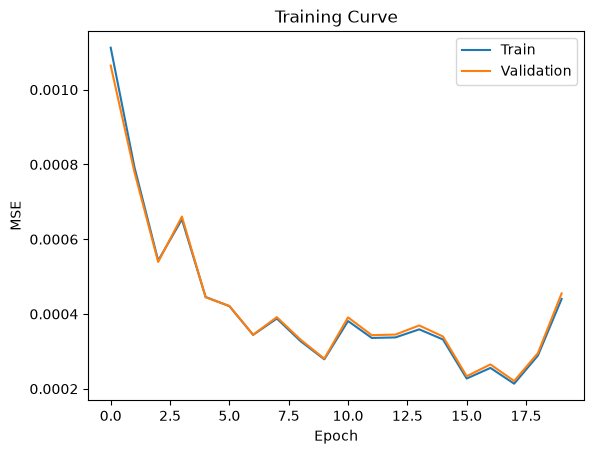

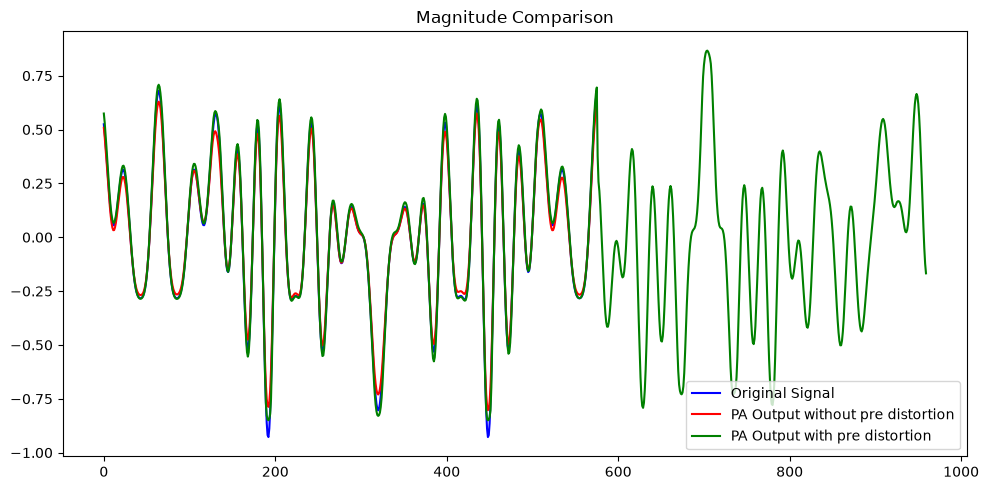

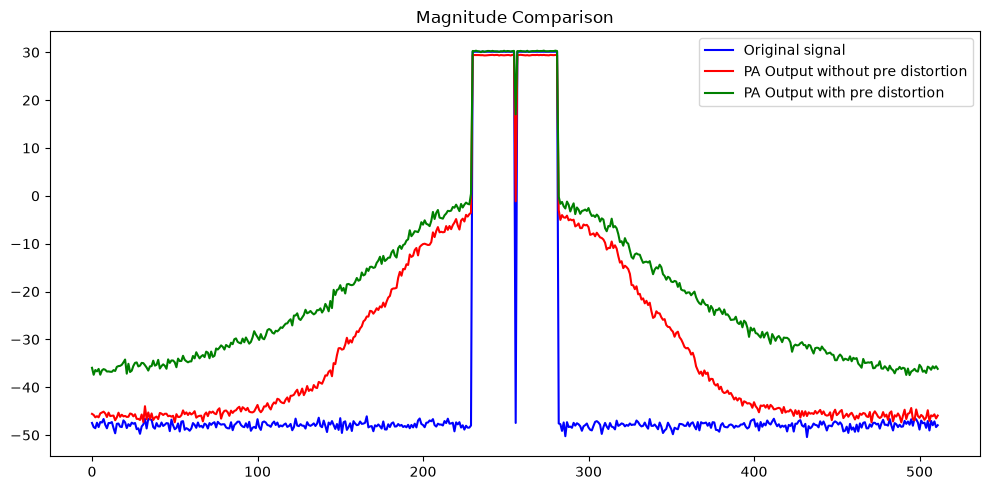

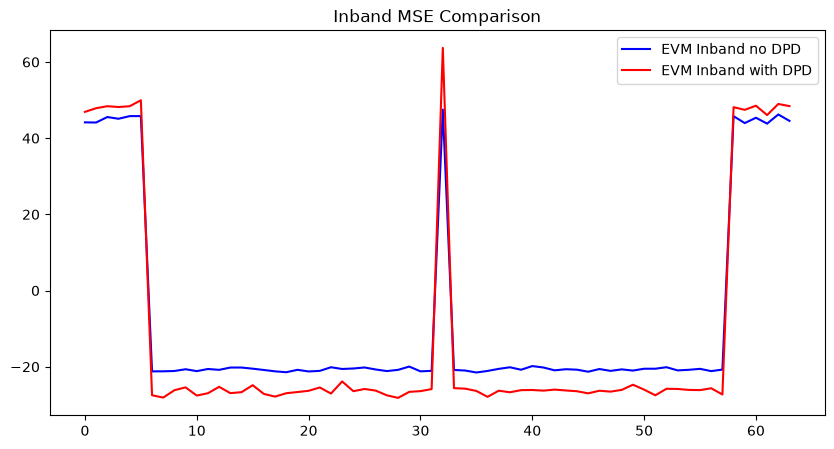

In [ ]:
RUN_OUTPUT_DIR = Path("runs") / datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_NFFT = config.Config.FFT_SIZE
_CP_LEN = config.Config.CP_LEN

# -----------------------------
# DPD GRU model definition
# -----------------------------
class DpdGru(nn.Module):
    def __init__(self, RNN_type, input_size, hidden_size, num_outputs, num_layers=1, fc1_size=100, fc2_size=64, dropout=0.1):
        super().__init__() #  The super() function is used to give access to methods and properties of a parent class
        self.hidden_size = hidden_size
        self.hidden = None
        self.rnn = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True) # batch_first=True means that the input and output tensors are provided as (batch, seq, feature)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, fc1_size),
            nn.ReLU(),
            nn.Linear(fc1_size, fc2_size),
            nn.ReLU(),
            nn.Linear(fc2_size, num_outputs)
        )

    def forward(self, x, h=None):
        # Sequence-to-sequence: return one output sample per input sample.
        rnn_out, h = self.rnn(x, h)
        out = self.head(rnn_out)
        return out, h


# --- orgenize OFDM data into batches -----
#   1. covert arrays of shape (2,N) to two tensors of shape (N,) with complex64 dtype
#   2. Splits the N//64 blocks of 64 samples.
#   3. Converts complex samples into real-valued I/Q pairs.
#   4. Reshapes each 64-sample block into 8 sequences of length 8
# -----------------------------------------
class OfdmBatcher:
    def __init__(self, ofdms, batch_size=64, drop_last=True, enhance_features=False):
        self.drop_last = drop_last
        self.enhance_features = enhance_features
        # convert multiple OFDM symbols into a single array of shape (2, N)
        ofdms = np.concatenate(ofdms, axis=1)
        # convert array of shape (2, N) to two tensors of shape (N,) with complex64 dtype
        pa_in_tens = torch.as_tensor(ofdms[0, :], dtype=torch.complex64)
        pa_out_tens = torch.as_tensor(ofdms[1, :], dtype=torch.complex64)

        self.batch_size = batch_size
        if drop_last:
            self.num_batches = pa_in_tens.shape[0] // batch_size
        else:
            self.num_batches = (pa_in_tens.shape[0] + batch_size - 1) // batch_size

        required_samples = self.num_batches * self.batch_size

        # Keep exactly 38 batches of 64 after skipping first/last 64 samples.
        self.pa_in = pa_in_tens[:required_samples]
        self.pa_out = pa_out_tens[:required_samples]

    # called on "for" loop to produce batches of data 
    def __iter__(self):
        for batch_idx in range(self.num_batches):
            start = batch_idx * self.batch_size
            end = start + self.batch_size
            pa_in_batch = self.pa_in[start:end]
            pa_out_batch = self.pa_out[start:end]

            if self.enhance_features:
                pa_in_ri = torch.stack((pa_in_batch.real, pa_in_batch.imag, pa_in_batch.real**2+pa_in_batch.imag**2,(pa_in_batch.real**2+pa_in_batch.imag**2)**2), dim=-1).view(1,self.batch_size , 4)
                pa_out_ri = torch.stack((pa_out_batch.real, pa_out_batch.imag, pa_out_batch.real**2+pa_out_batch.imag**2,(pa_out_batch.real**2+pa_out_batch.imag**2)**2), dim=-1).view(1, self.batch_size, 4)
            else:
                pa_in_ri = torch.stack((pa_in_batch.real, pa_in_batch.imag), dim=-1).view(1,self.batch_size , 2)
                pa_out_ri = torch.stack((pa_out_batch.real, pa_out_batch.imag), dim=-1).view(1, self.batch_size, 2)

            yield pa_in_ri, pa_out_ri

def get_mse(model, data_loader):
    total_loss, total_batches = 0.0, 0
    h = None

    # Evaluate without gradient tracking and restore mode after metric pass.
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for pa_in, pa_out in data_loader:
            pa_out, pa_in = pa_out.to(device), pa_in.to(device)
            pred, h = model(pa_out, h)
            total_loss += criterion(pred, pa_in).item()  # Only consider the first two features (I/Q) for loss calculation
            total_batches += 1
            h = h.detach()

    if was_training:
        model.train()

    return total_loss / max(1, total_batches)

def train(model, optimizer, num_epochs=10):
    train_mse, valid_mse = [], []
    epochs = []
    # Loop over epochs

    model = model.to(device)
    for epoch in range(num_epochs):
        # Loop over batches
        h = None
        for pa_in, pa_out in train_loader:
            pa_out, pa_in = pa_out.to(device), pa_in.to(device)
            optimizer.zero_grad()
            pred, h = model(pa_out, h)
            loss = criterion(pred, pa_in)
            loss.backward()
            optimizer.step()
            h = h.detach()
        # Save error on each epoch
        train_mse.append(get_mse(model, train_loader))
        valid_mse.append(get_mse(model, valid_loader))
        print("Epoch %d; Loss %f; Train MSE %f; Val MSE %f" % (
              epoch+1, loss, train_mse[-1], valid_mse[-1]))
    # plotting
    plt.title("Training Curve")
    plt.plot(train_mse, label="Train")
    plt.plot(valid_mse, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend(loc='best')

# configuraton parameters for the GRU model and training
enhance_features = False    # use higher order features (power and power squared) in addition to I/Q
dropout = 0.1              # dropout rate for GRU layer
hidden_gru_size = 64       # number of hidden units in the GRU layer
num_gru_layers = 2          # number of GRU layers
num_of_epochs = 20          # number of epochs to train the model
fc1_size = 64              # number of units in the first fully connected layer
fc2_size = 32               # number of units in the second fully connected layer
lrs = [2e-4, 5e-5, 5e-5]    # ADAM learning rates for each stage of training (3 stages)
num_ofdm_sym = 50           # number of OFDM symbols to generate for training, validation, and testing
if enhance_features:
    input_size = 4
    num_outputs = 4
else:
    input_size = 2
    num_outputs = 2


criterion = nn.MSELoss()

 # --- Signal generation --------------------
 # 1. genearte OFDM signal at time domain
 # 2. add AWGN to ogenerated signal
 # 3. apply PA model to the signal
 # 4. store into an array of shape (3, 2, _NFFT+_CP_LEN) 
 #      where the first dimension is train/valid/test, 
 #      the second dimension is PA input/output, 
 #      and the third dimension is the time samples
 # -----------------------------------------
gru_raw_data = np.empty((3*num_ofdm_sym, 2, _NFFT+_CP_LEN), dtype=complex)
for i in range(3*num_ofdm_sym): 
    tx_iq = gen_lsig(bypass=False, repeat_bits_every_call=False, bits_seed=123, signal_rms_dbp=-7)
    # --- AWGN channel ---
    tx_pa_in_iq = apply_awgn(tx_iq, snr_db=70, bypass=False)
    # --- PA / channel model ---
    rf_out = apply_pa_model(tx_pa_in_iq, bypass=False)
    gru_raw_data[i,0,:]= tx_pa_in_iq
    gru_raw_data[i,1,:]= rf_out

train_data = gru_raw_data[: num_ofdm_sym, :, :]
valid_data = gru_raw_data[1*num_ofdm_sym : 2*num_ofdm_sym, :, :]
test_data = gru_raw_data[2*num_ofdm_sym : 3*num_ofdm_sym, :, :]  

# Divide data into batches
train_loader = OfdmBatcher(train_data, batch_size=64, drop_last=True, enhance_features=enhance_features)
valid_loader = OfdmBatcher(valid_data, batch_size=64, drop_last=True, enhance_features=enhance_features)
test_loader = OfdmBatcher(test_data, batch_size=64, drop_last=True, enhance_features=enhance_features)

model = DpdGru(nn.GRU, input_size=input_size, hidden_size=hidden_gru_size, num_outputs=num_outputs, num_layers=num_gru_layers, fc1_size=fc1_size, fc2_size=fc2_size, dropout=dropout).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=lrs[0]
)
# Train and produce training curve and validation curve
train(model, optimizer, num_epochs=num_of_epochs)


# run inference on test data and check the results
pa_in_pred_reshaped = np.array([])
model.eval()
with torch.no_grad():
    h = None
    for pa_in, pa_out in test_loader:
        pa_out, pa_in = pa_out.to(device), pa_in.to(device)
        pa_in_pred, h = model(pa_in, h)
        pa_in_pred_complex = torch.view_as_complex(pa_in_pred[..., :2]).reshape(-1)
        pa_in_pred_reshaped = np.append(pa_in_pred_reshaped, pa_in_pred_complex.cpu().numpy())

rf_out = apply_pa_model(pa_in_pred_reshaped, bypass=False)


# -------------------------------------
# meters and plot section
# -------------------------------------

# plot time domain portion of the signal
plt.figure(figsize=(10, 5))
plt.plot(test_data.real[0,0, 64:_NFFT//2], label='Original Signal', color='blue')
plt.plot(test_data.real[0,1, 64:_NFFT//2], label='PA Output without pre distortion', color='red')
plt.plot(rf_out.real[64:_NFFT//2], label='PA Output with pre distortion', color='green')
plt.title('Magnitude Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(RUN_OUTPUT_DIR / "time_domain_comparison.png", dpi=160)

# plot frequency domain magnitude
test_data_rs  = test_data[:,:,_CP_LEN//2:_NFFT+_CP_LEN//2]
test_data_fd = np.fft.fftshift(np.fft.fft(test_data_rs,axis=2),axes=2)
test_data_magdb_fd = 20*np.log10((np.mean(np.abs(test_data_fd),axis=0)))
rf_out_rs = rf_out.reshape(num_ofdm_sym,-1)[:,_CP_LEN//2:_NFFT+_CP_LEN//2]
rf_out_fd = np.fft.fftshift(np.fft.fft(rf_out_rs,axis=1),axes=1)
rf_out_magdb_fd = 20*np.log10(np.mean(np.abs(rf_out_fd),axis=0))

plt.figure(figsize=(10, 5))
plt.plot(test_data_magdb_fd[0, :], label='Original signal', color='blue')
plt.plot(test_data_magdb_fd[1, :], label='PA Output without pre distortion', color='red')
plt.plot(rf_out_magdb_fd, label='PA Output with pre distortion', color='green')
plt.title('Magnitude Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(RUN_OUTPUT_DIR / "frequency_domain_comparison.png", dpi=160)

# calculate inband MSE comparison
test_data_ib_fd_no_predistorsion = test_data_fd[:,:,_NFFT//2-32:_NFFT//2+32]
mse_ib_no_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-test_data_ib_fd_no_predistorsion[:,1,:])**2,axis=0)
evm_ib_db_no_predistorsion = 10*np.log10(mse_ib_no_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

mse_ib_with_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-rf_out_fd[:,_NFFT//2-32:_NFFT//2+32])**2,axis=0)
evm_ib_db_with_predistorsion = 10*np.log10(mse_ib_with_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

# calculate time domain MSE comparison
mse_td_no_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-test_data_rs[:,1,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
mse_td_with_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-rf_out_rs[:,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
evm_td_no_predistorsion = 10*np.log10(mse_td_no_predistorsion/np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1)))
evm_td_with_predistorsion = 10*np.log10(mse_td_with_predistorsion/np.mean(np.abs(test_data_rs[:,0,64:-64])**2,axis=(0,1)))

print("EVM time domain no DPD: ", evm_td_no_predistorsion)
print("EVM time domain with DPD: ", evm_td_with_predistorsion)


plt.figure(figsize=(10, 5))
plt.plot(evm_ib_db_no_predistorsion, label='EVM Inband no DPD', color='blue')
plt.plot(evm_ib_db_with_predistorsion, label='EVM Inband with DPD', color='red')
plt.title('Inband MSE Comparison')
plt.legend()
plt.show()

xx = 1